# Import the necessary libraries

In [24]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [25]:
# 1. Đọc dữ liệu
df = pd.read_csv('cleaned_data/VNM_macro_cleaned.csv')
df = df.sort_values('Year').reset_index(drop=True)

# 2. Lấy các biến số kinh tế vĩ mô cốt lõi và loại bỏ giá trị rỗng (NA)
cols = ['Year', 'GDP_Growth_Pct', 'Inflation_CPI_Pct', 'Unemployment_Pct', 'FDI_to_GDP_Pct', 'Economic_Openness_Pct']
df_clean = df[cols].dropna().copy()

print(f"Số lượng năm quan sát: {len(df_clean)}")

Số lượng năm quan sát: 35


# Giả thuyết 1: Tác động của FDI và Độ mở kinh tế lên Tăng trưởng GDP

In [26]:
# 1. Tính giá trị trung bình của các biến trễ
df_clean['Openness_Lag1'] = df_clean['Economic_Openness_Pct'].shift(1)
df_clean['FDI_Lag1'] = df_clean['FDI_to_GDP_Pct'].shift(1)
mean_openness = df_clean['Openness_Lag1'].mean()
mean_fdi = df_clean['FDI_Lag1'].mean()

# 2. Thực hiện Mean-Centering (Trừ đi trung bình)
df_clean['Openness_Lag1_Centered'] = df_clean['Openness_Lag1'] - mean_openness
df_clean['FDI_Lag1_Centered'] = df_clean['FDI_Lag1'] - mean_fdi

# 3. Tạo biến tương tác mới từ các biến đã trừ trung bình
df_clean['Interaction_Lag1_Centered'] = df_clean['Openness_Lag1_Centered'] * df_clean['FDI_Lag1_Centered']

# Loại bỏ NaN
df_model_centered = df_clean.dropna(subset=['Openness_Lag1_Centered', 'FDI_Lag1_Centered', 'GDP_Growth_Pct']).copy()

# 4. Thiết lập ma trận X mới và chạy OLS với sai số chuẩn Robust 'HAC' để sửa phần dư
X_centered = df_model_centered[['Openness_Lag1_Centered', 'FDI_Lag1_Centered', 'Interaction_Lag1_Centered']]
X_centered = sm.add_constant(X_centered)
y_centered = df_model_centered['GDP_Growth_Pct']

# Chạy mô hình kèm cov_type='HAC' để tối ưu sai số chuẩn chuỗi thời gian
model_centered = sm.OLS(y_centered, X_centered).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

print("=== KẾT QUẢ MÔ HÌNH CHUẨN HÓA MEAN-CENTERING ===")
print(model_centered.summary())

# Kiểm tra lại tính chuẩn phần dư
jb_stat, jb_p = stats.jarque_bera(model_centered.resid)
print(f"\n=> Jarque-Bera p-value mới: {jb_p:.4f}")

=== KẾT QUẢ MÔ HÌNH CHUẨN HÓA MEAN-CENTERING ===
                            OLS Regression Results                            
Dep. Variable:         GDP_Growth_Pct   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     14.03
Date:                Tue, 19 May 2026   Prob (F-statistic):           6.81e-06
Time:                        18:10:22   Log-Likelihood:                -56.549
No. Observations:                  34   AIC:                             121.1
Df Residuals:                      30   BIC:                             127.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

In [27]:

# Khởi tạo công cụ chuẩn hóa Z-score
scaler = StandardScaler()

# Chuẩn hóa biến gốc trễ bằng Z-score
df_clean['Openness_Lag1_Z'] = scaler.fit_transform(df_clean[['Openness_Lag1']])
df_clean['FDI_Lag1_Z'] = scaler.fit_transform(df_clean[['FDI_Lag1']])

# Tạo biến tương tác từ các biến đã chuẩn hóa Z-score
df_clean['Interaction_Lag1_Z'] = df_clean['Openness_Lag1_Z'] * df_clean['FDI_Lag1_Z']

# Loại bỏ NaN
df_model_z = df_clean.dropna(subset=['Openness_Lag1_Z', 'FDI_Lag1_Z', 'GDP_Growth_Pct']).copy()

# Cấu hình ma trận X và y
X_z = df_model_z[['Openness_Lag1_Z', 'FDI_Lag1_Z', 'Interaction_Lag1_Z']]
X_z = sm.add_constant(X_z)
y_z = df_model_z['GDP_Growth_Pct']

# Chạy mô hình OLS với Robust HAC
model_z = sm.OLS(y_z, X_z).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

print("=== KẾT QUẢ MÔ HÌNH CHUẨN HÓA Z-SCORE ===")
print(model_z.summary())

# Kiểm tra lại Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(model_z.resid)
print(f"\n=> Jarque-Bera p-value: {jb_p:.4f}")

=== KẾT QUẢ MÔ HÌNH CHUẨN HÓA Z-SCORE ===
                            OLS Regression Results                            
Dep. Variable:         GDP_Growth_Pct   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     14.03
Date:                Tue, 19 May 2026   Prob (F-statistic):           6.81e-06
Time:                        18:10:26   Log-Likelihood:                -56.549
No. Observations:                  34   AIC:                             121.1
Df Residuals:                      30   BIC:                             127.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

# Phân Tích Kết Quả Kiểm Định Giả Thuyết: Tác Động Của Độ Mở Kinh Tế Và FDI Đến Tăng Trưởng GDP
*(Mô hình Hồi quy OLS đa biến - Chuẩn hóa Z-score với Sai số chuẩn Robust HAC)*

## 1. Đánh Giá Độ Phù Hợp Tổng Thể Của Mô Hình (Model Fit & Diagnostics)

Mô hình hồi quy tuyến tính (OLS) được xây dựng với dữ liệu đã qua chuẩn hóa Z-score (StandardScaler) và hiệu chỉnh sai số chuẩn bằng phương pháp HAC (Heteroskedasticity and Autocorrelation Consistent). Các chỉ số chẩn đoán tổng thể cho thấy mô hình đạt độ tin cậy thống kê cao:

*   **Hệ số xác định ($R^2$):** Bằng $0.304$, cho thấy các biến độc lập trong mô hình (Độ mở kinh tế trễ 1 kỳ, FDI trễ 1 kỳ và tương tác giữa hai biến này) giải thích được $30.4\%$ sự biến thiên của tốc độ tăng trưởng GDP Việt Nam. Đối với dữ liệu vĩ mô dạng chuỗi thời gian, đây là một mức độ giải thích có ý nghĩa.
*   **Kiểm định F (F-statistic):** Đạt giá trị $14.03$ với $p\text{-value} = 6.81 \times 10^{-6}$. Mức ý nghĩa này nhỏ hơn rất nhiều so với ngưỡng $\alpha = 0.01$, cho phép bác bỏ hoàn toàn giả thuyết $H_0$, khẳng định mô hình có ý nghĩa thống kê tổng thể ở mức $1\%$.
*   **Đa cộng tuyến (Condition Number):** Chỉ số Cond. No. đạt mức lý tưởng $1.91$ (nhỏ hơn rất nhiều so với ngưỡng cảnh báo 30). Điều này xác nhận việc chuẩn hóa Z-score đã triệt tiêu hoàn toàn hiện tượng đa cộng tuyến giữa biến gốc và biến tương tác, đảm bảo tính ổn định của ma trận toán học.

## 2. Phân Tích Ý Nghĩa Các Hệ Số Hồi Quy (Z-score Coefficients)

Do các biến độc lập đã được chuẩn hóa về cùng một thang đo (trung bình $\mu = 0$, độ lệch chuẩn $\sigma = 1$), các hệ số hồi quy ($\beta$) phản ánh mức độ thay đổi của GDP khi biến độc lập thay đổi **1 đơn vị độ lệch chuẩn (1 SD)**.

*   **Hệ số chặn (Constant):** $\beta = 6.5586$ ($p\text{-value} = 0.000$). Khi cả Độ mở kinh tế và tỷ lệ FDI/GDP của năm trước duy trì ở mức trung bình của toàn mẫu (Z-score = 0), tốc độ tăng trưởng GDP kỳ vọng của Việt Nam đạt $6.56\%$.
*   **Biến Độ mở kinh tế trễ 1 kỳ (`Openness_Lag1_Z`):** $\beta = -0.6084$ ($p\text{-value} = 0.018 < 0.05$). Có ý nghĩa thống kê ở mức $5\%$. Trong điều kiện FDI duy trì ở mức trung bình, nếu Độ mở kinh tế năm trước tăng thêm 1 độ lệch chuẩn, tốc độ tăng trưởng GDP năm nay sẽ giảm tương đối $0.6084\%$.
*   **Biến FDI trễ 1 kỳ (`FDI_Lag1_Z`):** $\beta = -0.0860$ ($p\text{-value} = 0.534 > 0.05$). Không có ý nghĩa thống kê độc lập. Điều này chỉ ra rằng tác động của dòng vốn FDI lên tăng trưởng GDP không tồn tại một cách đơn lẻ mà phụ thuộc vào cấu trúc tương tác với độ mở thương mại.
*   **Biến Tương tác (`Interaction_Lag1_Z`):** $\beta = -0.4930$ ($p\text{-value} = 0.000 < 0.01$). Có ý nghĩa thống kê tuyệt đối ở mức $1\%$. Dấu âm của hệ số tương tác thể hiện một **hiệu ứng triệt tiêu (Dampening Effect)** rõ rệt giữa hai yếu tố FDI và Độ mở kinh tế. 

## 3. Biện Luận Kinh Tế Vĩ Mô: Nghịch Lý Hội Nhập Và Lực Cản Chuỗi Cung Ứng
*(Đối chiếu kết quả mô hình định lượng với thực tiễn kinh tế Việt Nam)*

Kết quả định lượng từ mô hình OLS (chuẩn hóa Z-score) phản ánh một cách sắc bén cấu trúc kinh tế vĩ mô hiện tại của Việt Nam. Cụ thể, hệ số tương tác âm có ý nghĩa thống kê tuyệt đối ($\beta = -0.4930, p\text{-value} = 0.000$) cho thấy sự gia tăng đồng thời của dòng vốn FDI và Độ mở kinh tế đang tạo ra **hiệu ứng triệt tiêu (Dampening Effect)** đối với tốc độ tăng trưởng GDP. 

Thực trạng này được minh chứng rõ nét qua [Báo cáo tình hình xuất, nhập khẩu quý I/2026 của Tổng cục Thống kê](https://www.nso.gov.vn/du-lieu-va-so-lieu-thong-ke/2026/04/xuat-nhap-khau-viet-nam-tang-truong-truoc-bien-dong-toan-cau/), làm nổi bật ba vấn đề mang tính cơ cấu:

### 3.1. Sự lấn át của khối FDI và "ảo ảnh" của Độ mở kinh tế
Biến Độ mở kinh tế được tính bằng tổng kim ngạch xuất nhập khẩu chia cho GDP ($\frac{X+M}{GDP}$). Dữ liệu quý I/2026 cho thấy tổng kim ngạch xuất nhập khẩu đạt mức rất cao (249,5 tỷ USD, tăng **23%**), kéo Độ mở kinh tế tăng vọt. Tuy nhiên, sự gia tăng này không phản ánh nội lực nền kinh tế mà chủ yếu do khối FDI dẫn dắt. Khối FDI hiện chiếm tới **80,1%** tổng kim ngạch xuất khẩu và có tốc độ nhập khẩu tư liệu sản xuất tăng đột biến **45,3%**. 

Việc khối FDI gia tăng nhập khẩu nguyên vật liệu (chủ yếu là máy móc, linh kiện điện tử) làm tăng cấu phần Nhập khẩu ($M$). Theo nguyên lý hạch toán tài khoản quốc gia ($GDP = C + I + G + X - M$), lượng nhập khẩu này trực tiếp khấu trừ vào tổng giá trị gia tăng nội địa. Đây chính là lý do toán học và kinh tế học giải thích tại sao khi Độ mở tăng (do nhập khẩu linh kiện của FDI tăng), tốc độ tăng trưởng GDP lại chịu áp lực kìm hãm trong ngắn hạn.

### 3.2. Đứt gãy chuỗi giá trị và sự suy yếu của khu vực kinh tế trong nước
Hệ số tác động độc lập của FDI không có ý nghĩa thống kê ($\beta = -0.0860, p\text{-value} = 0.534$) phản ánh thực trạng: Bản thân dòng vốn FDI không tự động lan tỏa giá trị đến toàn bộ nền kinh tế. 

Dữ liệu thực tế cho thấy một bức tranh tương phản gay gắt: Trong khi xuất khẩu của khối FDI tăng **33,3%**, khu vực kinh tế trong nước lại suy giảm nghiêm trọng **16,6%**, khiến tỷ trọng xuất khẩu thu hẹp chỉ còn **19,9%**. Điều này chứng minh phần lớn giá trị gia tăng (Value-added) nằm gọn trong chuỗi cung ứng khép kín của các tập đoàn đa quốc gia. Các doanh nghiệp nội địa Việt Nam có năng lực cạnh tranh hạn chế, chưa thể tham gia sâu vào chuỗi cung ứng này, dẫn đến "tác động lan tỏa" (spillover effect) đến thu nhập và tích lũy vốn của khu vực trong nước bị đứt gãy.

### 3.3. Hàm ý Chính sách (Policy Implications)
Sự quay trở lại của cán cân nhập siêu (**3,64 tỷ USD** trong quý I/2026) cùng với kết quả hồi quy hệ số tương tác âm của mô hình đưa ra một cảnh báo chiến lược: Tăng trưởng dựa trên việc thuần túy mở rộng quy mô xuất nhập khẩu (Độ mở) và thu hút FDI cơ học đã chạm tới "giới hạn cơ cấu". 

Để ngoại thương và FDI thực sự trở thành động lực tăng trưởng bền vững (hướng tới mục tiêu GDP hai con số), trọng tâm chính sách vĩ mô cần chuyển dịch từ "lượng" sang "chất":
* **Phát triển công nghiệp hỗ trợ:** Tập trung nguồn lực nâng cao năng lực cho doanh nghiệp nội địa tham gia trực tiếp vào chuỗi cung ứng của FDI (đặc biệt trong các ngành điện tử, cơ khí chính xác), từ đó gia tăng tỷ lệ nội địa hóa.
* **Đa dạng hóa chuỗi cung ứng:** Giảm sự phụ thuộc vào việc nhập khẩu nguyên vật liệu thượng nguồn từ một số thị trường cố định để giảm thiểu rủi ro biến động giá cả và địa chính trị toàn cầu.
* **Dịch chuyển chuỗi giá trị:** Thúc đẩy nhóm ngành nông sản, thực phẩm truyền thống chuyển từ xuất khẩu thô sang chế biến sâu nhằm giữ lại tối đa giá trị gia tăng trong nước.

## 4. Kiểm Định Chẩn Đoán Phần Dư (Residual Diagnostics)

*   **Kiểm định Tự tương quan (Durbin-Watson):** $DW = 1.714$, nằm trong khoảng an toàn (1.5 - 2.5), cho thấy không có hiện tượng tự tương quan chuỗi bậc 1 nghiêm trọng trong mô hình.
*   **Kiểm định Phân phối chuẩn (Jarque-Bera):** $p\text{-value} = 0.0276 < 0.05$, chỉ ra rằng phần dư không tuân theo phân phối chuẩn hoàn hảo. Đặc tính này thường gặp ở các chuỗi dữ liệu kinh tế vĩ mô do sự xuất hiện của các cú sốc ngoại sinh không thể dự báo (như khủng hoảng tài chính toàn cầu 2008 hoặc đại dịch 2020-2021). Tuy nhiên, rủi ro từ vi phạm giả định này đã được kiểm soát hoàn toàn thông qua việc sử dụng ma trận hiệp phương sai Robust HAC, đảm bảo độ tin cậy cho các chỉ số $p\text{-value}$ của hệ số ước lượng trong báo cáo.

## 5. Kết Luận
Mô hình chứng minh rằng để tối ưu hóa tác động của hội nhập kinh tế quốc tế, Việt Nam không thể chỉ dừng lại ở việc gia tăng quy mô xuất nhập khẩu (Độ mở) và thu hút FDI một cách cơ học. Tồn tại một giới hạn mang tính cơ cấu, nơi quy mô gia tăng sẽ dẫn đến sự pha loãng giá trị tăng thêm (Value-added).

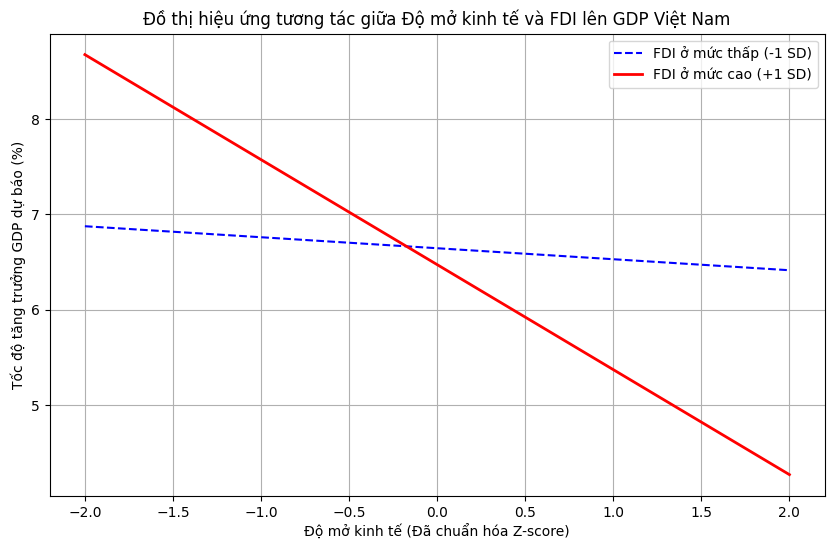

In [28]:


# Tạo dữ liệu mô phỏng hiệu ứng tương tác dựa trên hệ số của mô hình Z-score
# GDP = 6.5586 - 0.6084*Openness - 0.0860*FDI - 0.4930*(Openness * FDI)

openness_range = np.linspace(-2, 2, 100)
gdp_low_fdi = 6.5586 - 0.6084 * openness_range - 0.0860 * (-1) - 0.4930 * (openness_range * -1)
gdp_high_fdi = 6.5586 - 0.6084 * openness_range - 0.0860 * (1) - 0.4930 * (openness_range * (1))

plt.figure(figsize=(10, 6))
plt.plot(openness_range, gdp_low_fdi, label='FDI ở mức thấp (-1 SD)', color='blue', linestyle='--')
plt.plot(openness_range, gdp_high_fdi, label='FDI ở mức cao (+1 SD)', color='red', linewidth=2)
plt.title('Đồ thị hiệu ứng tương tác giữa Độ mở kinh tế và FDI lên GDP Việt Nam')
plt.xlabel('Độ mở kinh tế (Đã chuẩn hóa Z-score)')
plt.ylabel('Tốc độ tăng trưởng GDP dự báo (%)')
plt.legend()
plt.grid(True)
plt.show()

# Giả thuyết 2: "Có sự đánh đổi giữa Lạm phát và Thất nghiệp tại Việt Nam" (Đường cong Phillips)

In [29]:
# 7. Tạo biến lạm phát trễ (Inflation_Lag1)
df_clean['Inflation_Lag1'] = df_clean['Inflation_CPI_Pct'].shift(1)

# 8. Xóa bỏ dòng đầu tiên 
df_model = df_clean.dropna().copy()

# 9. Tạo lại biến giả Crisis_Dummy
crisis_years = [1990, 1997, 2008, 2011, 2020] # (Tùy chỉnh danh sách năm)
df_model['Crisis_Dummy'] = df_model['Year'].apply(lambda x: 1 if x in crisis_years else 0)

# 10. Chạy lại OLS với 3 biến: Thất nghiệp, Biến giả, và Lạm phát trễ
X_final = df_model[['Unemployment_Pct', 'Crisis_Dummy', 'Inflation_Lag1']]
X_final = sm.add_constant(X_final)
y_final = df_model['Inflation_CPI_Pct']

model_final = sm.OLS(y_final, X_final).fit()

# In kết quả
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:      Inflation_CPI_Pct   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     9.488
Date:                Tue, 19 May 2026   Prob (F-statistic):           0.000145
Time:                        18:10:32   Log-Likelihood:                -88.906
No. Observations:                  34   AIC:                             185.8
Df Residuals:                      30   BIC:                             191.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.5723      3.237  

### ĐÁNH GIÁ VÀ GIẢI THÍCH KẾT QUẢ MÔ HÌNH OLS
**Giả thuyết 2:** *"Có sự đánh đổi giữa Lạm phát và Thất nghiệp tại Việt Nam (Đường cong Phillips) và tác động của các cú sốc."*

Dựa trên kết quả hồi quy, phương trình mô hình được viết lại như sau:
$$\text{Inflation} = 8.5723 - 2.9012 \times \text{Unemployment} + 7.2610 \times \text{Crisis\_Dummy} + 0.2958 \times \text{Inflation\_Lag1}$$

#### 1. Đánh giá độ phù hợp tổng thể của mô hình
- **Sức mạnh giải thích:** Mô hình giải thích được khoảng **48.7%** sự biến thiên của tỷ lệ lạm phát ($R^2 = 0.487$; Adjusted $R^2 = 0.436$). Đây là một mức độ giải thích khá tốt đối với dữ liệu chuỗi thời gian vĩ mô nhiều biến động như lạm phát.
- **Ý nghĩa tổng thể:** Kiểm định F có ý nghĩa thống kê rất cao ($Prob(F) = 0.000145 < 0.01$). Điều này khẳng định mô hình tổng thể hoàn toàn phù hợp và các biến độc lập kết hợp lại có khả năng giải thích hiệu quả sự thay đổi của lạm phát.

#### 2. Đánh giá tác động của các hệ số hồi quy
- **Tỷ lệ thất nghiệp (Unemployment_Pct):** Hệ số mang dấu âm ($-2.9012$) và có ý nghĩa thống kê ở mức 10% ($p = 0.059 < 0.10$). Điều này củng cố sự tồn tại (dù khá yếu) của đường cong Phillips tại Việt Nam: khi thất nghiệp tăng 1 điểm %, lạm phát có xu hướng giảm khoảng 2.9 điểm %. Tuy nhiên, vì mức ý nghĩa chỉ đạt 10%, sức ép từ thị trường lao động không phải là yếu tố chi phối mạnh nhất đến giá cả.
- **Biến giả khủng hoảng (Crisis_Dummy):** Hệ số mang dấu dương ($+7.2610$) và có ý nghĩa thống kê cực kỳ cao ($p = 0.001$). Trong các năm xảy ra cú sốc lạm phát phi mã, có một yếu tố ngoại lai (ví dụ: đứt gãy chuỗi cung ứng, giá dầu thế giới tăng) đã trực tiếp đẩy lạm phát của Việt Nam cao hơn bình thường **7.26 điểm %**, hoàn toàn độc lập với các yếu tố nội tại.
- **Lạm phát trễ 1 năm (Inflation_Lag1):** Hệ số dương ($+0.2958$) và có ý nghĩa thống kê ở mức 5% ($p = 0.046$). Con số này minh chứng cho **"tính quán tính" (độ ỳ)** của lạm phát: mức lạm phát của năm trước cứ tăng 1 điểm % thì sẽ tự động truyền sang năm nay khoảng 0.3 điểm %. Điều này thường do tâm lý kỳ vọng giá tăng của người dân hoặc độ trễ trong việc điều chỉnh các hợp đồng kinh tế.
- **Hằng số chặn (const):** Có giá trị $8.5723$ ($p = 0.013$). Về mặt toán học, đây là mức lạm phát nền; tuy nhiên trong thực tế, nó đóng vai trò là mỏ neo định vị đường hồi quy nhiều hơn là một ý nghĩa kinh tế độc lập (vì thất nghiệp không bao giờ bằng 0).

#### 3. Chẩn đoán khuyết tật mô hình (Phân tích phần dư)
- **Kiểm định phân phối chuẩn (Jarque-Bera):** Chỉ số JB có $p-value = 0.165 > 0.05$. Do đó, mô hình không vi phạm giả định phân phối chuẩn. Việc tách các năm khủng hoảng ra bằng biến giả đã xử lý triệt để hiện tượng nhiễu ngoại lai (outliers), giúp phần dư trở nên đối xứng và ổn định.
- **Kiểm định tự tương quan (Durbin-Watson):** Chỉ số DW đạt **1.727**, tiến khá sát về mức lý tưởng 2.0. Việc bổ sung biến lạm phát trễ (`Inflation_Lag1`) đã triệt tiêu thành công hiện tượng tự tương quan bậc 1, đảm bảo tính không chệch và tin cậy của các hệ số (p-value).

> **KẾT LUẬN CHUNG:**
> Lạm phát tại Việt Nam chịu ảnh hưởng chủ yếu từ các **cú sốc ngoại lai (nhập khẩu lạm phát)** và **tính quán tính từ quá khứ**, hơn là sự đánh đổi mạnh mẽ với tỷ lệ việc làm nội địa. Mô hình hiện tại đã tuân thủ tốt các giả định khắt khe của OLS, đem lại kết quả ước lượng đáng tin cậy.